### Create 2K AV sets ; split train/test 1K/1K
    1. Test data: 1K
    2. Train data: 1K
    Check that the test data does not contain entries of the training????? Kind of dificult since the most common cases may appear in real data several times, but can try


### Requirements: 
* pip install numpy
* pip install --force-reinstall \
  "numpy<2.3" \
  "pandas<3" \
  "python-dateutil>=2.8.2,<3" \
  "sdmetrics"
* pip install smartnoise-synth
* pip install sdv
* pip install -U mostlyai-qa
  

In [1]:
import numpy as np
import random
import pandas as pd
# pd.set_option('display.max_rows', None)
import torch
# from sklearn.preprocessing import OrdinalEncoder
import json
from snsynth import Synthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic
from sdmetrics.reports.single_table import QualityReport  # Optional detailed report
from sdv.metadata import SingleTableMetadata
from pathlib import Path
import os
import importlib
import sys
sys.path.append('lib/.')
import commonFc
importlib.reload(commonFc)

# torch.cuda.empty_cache()

<module 'commonFc' from '/home/jovyan/work/Aime26/EMNLP/TestTabularData/lib/./commonFc.py'>

In [2]:
from sdmetrics.single_table import DCRBaselineProtection
from sdmetrics.single_table import DCROverfittingProtection
from mostlyai import qa


# Load data


In [3]:
df_train50=pd.read_csv("data/tabular/train5_df_Mail.csv")
df_holdout50=pd.read_csv("data/tabular/holdout5_df_Mail.csv")
print(df_train50.shape,df_holdout50.shape)

df_train70=pd.read_csv("data/tabular/train_df_Mail.csv")
df_holdout30=pd.read_csv("data/tabular/holdout_df_Mail.csv")
print(df_train70.shape,df_holdout30.shape)

df_all=pd.read_csv("data/tabular/oneTumor_df_valid_Mail.csv")
print(df_all.columns)

(1940, 17) (1940, 17)
(2716, 17) (1164, 17)
Index(['row_id', 'type_diagnostique', 'ganglions_preleves',
       'ganglions_atteints', 'rupture_capsulaire', 't', 'n', 'm',
       'taille_tumor_0', 're_tumor_0', 'rp_tumor_0',
       'embols_vasculaires_tumor_0', 'cerb_tumor_0', 'marges_saines_tumor_0',
       'ki67_tumor_0', 'ref_morpho_name_tumor_0', 'ref_grade_tumor_0'],
      dtype='object')


In [4]:
# we won't extract t,n,m 
df_train50=df_train50.drop(['row_id','t', 'n', 'm'],axis=1)
df_holdout50=df_holdout50.drop(['row_id','t', 'n', 'm'],axis=1)
df_all=df_all.drop(['row_id','t', 'n', 'm'],axis=1)
df_train70=df_train70.drop(['row_id','t', 'n', 'm'],axis=1)
df_holdout30=df_holdout30.drop(['row_id','t', 'n', 'm'],axis=1)

In [5]:
df_all[df_all["type_diagnostique"]=="unknown"].shape

(886, 13)

In [6]:
df_all[df_all["ref_morpho_name_tumor_0"]=="unknown"].shape

(192, 13)

In [7]:
df_all.shape

(3880, 13)

In [8]:
# data is not so clean so clean some easy values otherwise i have not much left
# df_all.loc[
#     (df_all["type_diagnostique"].isin(["unknown"])) &
#      ~(df_all["taille_tumor_0"].isin(["unknown", "0"])),
#     "type_diagnostique"
# ] = "tumorectomie"

# df_all.loc[
#     (df_all["type_diagnostique"].isin(["unknown"])) &
#     (df_all["taille_tumor_0"].isin(["unknown","0"])) &
#     (df_all["ganglions_atteints"].isin(["1-3","4-9", "+10"])) ,
#     "type_diagnostique"
# ] = "tumorectomie"

df_all.loc[
    (df_all["type_diagnostique"].isin(["unknown"])) &
    (df_all["taille_tumor_0"].isin(["unknown", "0"])) &
    (df_all["ganglions_preleves"].isin(["unknown"])),
    "type_diagnostique"
] = "biopsie"


df_all.loc[
    df_all["type_diagnostique"].isin(["biopsie","curage ganglionnaire"]),
    "marges_saines_tumor_0"
] = "unknown"

# df_all.loc[
#     ~(df_all["taille_tumor_0"].isin(["unknown","0"])) &
#         (df_all["marges_saines_tumor_0"]=="unknown"),
#     "marges_saines_tumor_0"
# ] = "oui"




In [9]:
# clean data just in case: 
df_train50 = df_train50[df_train50.apply(lambda row: commonFc.check_constraints_noTNM(row, False), axis=1)]
df_holdout50 = df_holdout50[df_holdout50.apply(lambda row: commonFc.check_constraints_noTNM(row, False), axis=1)]
df_all = df_all[df_all.apply(lambda row: commonFc.check_constraints_noTNM(row, False), axis=1)]
df_holdout30 = df_holdout30[df_holdout30.apply(lambda row: commonFc.check_constraints_noTNM(row, False), axis=1)]


In [10]:
from sklearn.model_selection import train_test_split

df_train70, df_holdout30 = train_test_split(
    df_all, 
    test_size=0.3,   # 30% test → 70% train
    random_state=42  # for reproducibility
)

In [11]:
print(df_all.shape)
print(df_train70.shape)
print(df_holdout30.shape)

(2650, 13)
(1855, 13)
(795, 13)


In [12]:
print(df_all.columns)


Index(['type_diagnostique', 'ganglions_preleves', 'ganglions_atteints',
       'rupture_capsulaire', 'taille_tumor_0', 're_tumor_0', 'rp_tumor_0',
       'embols_vasculaires_tumor_0', 'cerb_tumor_0', 'marges_saines_tumor_0',
       'ki67_tumor_0', 'ref_morpho_name_tumor_0', 'ref_grade_tumor_0'],
      dtype='object')


# Run tests 50 - 50

In [13]:
# Create metadata
# metadata = Metadata.detect_from_dataframe(df_encoded)
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=df_all)
metadata_dict = metadata.to_dict()

In [14]:
def call_eval_sdmetricsQuality(df_train,df_holdout,synth_data,metadata):
    # 1. Diagnostic checks for validity
    diagnostic = run_diagnostic(df_train, synth_data, metadata)
    
    # 2. Statistical similarity scoring
    quality_report = evaluate_quality(df_train, synth_data, metadata)
    
    # You can inspect the overall quality score:
    print("Overall Quality Score:", quality_report.get_score())
    
    # 3. (Optional) In-depth report with SDMetrics
    report = QualityReport()
    report.generate(df_train, synth_data, metadata_dict)
    print("Detailed properties:\n", report.get_properties())
    return quality_report.get_score(), report.get_properties()


In [15]:

def compute_dcrBaselineProtection(df_real,df_synth,metadata_dict):
    score = DCRBaselineProtection.compute_breakdown(
        real_data=df_real,
        synthetic_data=df_synth,
        metadata=metadata_dict
    )
    # print(score)
    return score



def compute_DCROverfittingProtection(training_table,holdout_table,synthetic_table,metadata_dictionary):
    score = DCROverfittingProtection.compute_breakdown(
        real_training_data=training_table,
        synthetic_data=synthetic_table,
        real_validation_data=holdout_table,
        metadata=metadata_dictionary
    )
    # print(score)
    return score

In [16]:

# initialize logging to stdout
qa.init_logging()

def callMakeReport(df_train,df_holdout, data_list,method):
    results = []
    for synthdata in data_list:
        report_path="data/tabular/Generation/benchmarkMostrlyAI.html"
        print(report_path,len(synthdata))
        # analyze single-table data
        report_path1, metrics = qa.report(
            syn_tgt_data = synthdata,
            trn_tgt_data = df_train,
            hol_tgt_data = df_holdout,  # optional
            report_path=report_path,
            max_sample_size_accuracy=100000,
        )
        # pretty print metrics
        print(metrics.model_dump_json(indent=4))
        results.append(metrics)
    return results

# Run directly on PateCTGAN
See Aime tabular data for comparison between synthetyzers and tunning of patectgan

In [17]:
BASE_SEED = 42
seed = BASE_SEED

np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def correct_insitu(df):
    in_situ=["carcinome in situ","carcinome intracanalaire non infiltrant","carcinome lobulaire in situ",
             "adenocarcinome in situ","carcinome intracanalaire et carcinome lobulaire in situ"]
    
    # to have more insitu (removed by the constraints) 
    df.loc[
        df["ref_morpho_name_tumor_0"].isin(in_situ),
        "embols_vasculaires_tumor_0"
    ] = "unknown"
    df.loc[
        df["ref_morpho_name_tumor_0"].isin(in_situ),
        "ganglions_preleves"
    ] = "unknown"
    df.loc[
        df["ref_morpho_name_tumor_0"].isin(in_situ),
        "ref_grade_tumor_0"
    ] = "unknown"
    # to have more biopsies (removed by the constraints) 
    df.loc[
        df["type_diagnostique"].isin(["biopsie","curage ganglionnaire"]),
        "taille_tumor_0"
    ] = "unknown"


    
    return df 

categorical_cols = list(df_train70.columns)
synth_p = Synthesizer.create(
    'patectgan',
    epsilon=3.0,
    delta=1e-5,
    epochs=400,
    batch_size=512,
    embedding_dim=256,
    generator_dim=(256, 512),
    discriminator_dim=(128, 128),
    verbose=True,
)

synth_p.fit(df_train70,
        categorical_columns=categorical_cols,
        continuous_columns=[],      # explicitly empty
        ordinal_columns=[],         # explicitly empty            
            preprocessor_eps=0.0  # no budget for preprocessing; all cat columns 
            )
final_synthetic_data = synth_p.sample(len(df_train70))
final_synthetic_data=correct_insitu(final_synthetic_data)
final_valid_rows_pate = final_synthetic_data[final_synthetic_data.apply(lambda row: commonFc.check_constraints_noTNM(row, False), axis=1)]

num_rows=len(final_valid_rows_pate)
while num_rows < 2000:
    synthetic_pate1=synth_p.sample(500)
    synthetic_pate1=correct_insitu(synthetic_pate1)
    valid_rows_pate1 = synthetic_pate1[synthetic_pate1.apply(lambda row: commonFc.check_constraints_noTNM(row, False), axis=1)]
    final_valid_rows_pate=pd.concat([final_valid_rows_pate,valid_rows_pate1], ignore_index=True)
    num_rows=len(final_valid_rows_pate)
# save synthetic data
final_synthetic_data.to_csv(f"data/tabular/Generation/final_synthetic_pateCustom.csv", index=False)    
final_valid_rows_pate.to_csv(f"data/tabular/Generation/final_valid_rows_pateCustomAll.csv", index=False)
    



/home/jovyan/work/Aime26/EMNLP/ddkdRagEnv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


using loss cross_entropy and regularization None
eps: 0.115129 	 G: 2.406800 	 D: 0.719052
eps: 0.490716 	 G: 2.432126 	 D: 0.725822
eps: 0.697015 	 G: 2.382674 	 D: 0.711004
eps: 0.856485 	 G: 2.321451 	 D: 0.729323
eps: 0.991705 	 G: 2.317194 	 D: 0.711748
eps: 1.111435 	 G: 2.299217 	 D: 0.761600
eps: 1.220343 	 G: 2.291569 	 D: 0.745075
eps: 1.320567 	 G: 2.310072 	 D: 0.752690
eps: 1.414511 	 G: 2.224291 	 D: 0.763921
eps: 1.502918 	 G: 2.253624 	 D: 0.793855
eps: 1.586728 	 G: 2.207462 	 D: 0.757460
eps: 1.667152 	 G: 2.228646 	 D: 0.772164
eps: 1.743952 	 G: 2.154368 	 D: 0.762710
eps: 1.817450 	 G: 2.134802 	 D: 0.753181
eps: 1.889130 	 G: 2.093747 	 D: 0.748473
eps: 1.957811 	 G: 2.103096 	 D: 0.795795
eps: 2.024371 	 G: 2.069091 	 D: 0.781323
eps: 2.090931 	 G: 2.105802 	 D: 0.746427
eps: 2.152550 	 G: 2.027196 	 D: 0.787795
eps: 2.213990 	 G: 1.972441 	 D: 0.768684
eps: 2.275430 	 G: 2.030220 	 D: 0.739900
eps: 2.334012 	 G: 1.974500 	 D: 0.765022
eps: 2.390332 	 G: 2.070052

In [18]:
# call evaluations
# 70/30 holdout is too small!!!!!
q_rep_final, rep_final= call_eval_sdmetricsQuality(df_train70,df_holdout30,final_valid_rows_pate,metadata)
dcrBase_score_final = compute_dcrBaselineProtection(df_train70,final_valid_rows_pate,metadata_dict)    
overfit_score_final = compute_DCROverfittingProtection(df_train70, df_holdout30, final_valid_rows_pate ,metadata_dict)
metricsPatectgan_final= callMakeReport(df_train70, df_holdout30, [final_valid_rows_pate], f"final_pate")    
Final_metrics_pate={"overal_quality_sdm":q_rep_final,
                     "quality_report_sdm":rep_final.to_dict(),
                     "dcrbaselineScore_sdm":dcrBase_score_final,
                     "dcroverfitScore_sdm":overfit_score_final,
                     "mostlyIA": metricsPatectgan_final
                      }


Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 1133.85it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 379.44it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 765.89it/s]|
Column Shapes Score: 94.31%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 231.74it/s]|
Column Pair Trends Score: 80.21%

Overall Score (Average): 87.26%

Overall Quality Score: 0.8726004596635157
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 841.84it/s]|
Column Shapes Score: 94.31%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 229.98it/s]|
Column Pair Trends Score: 80.21%

Overall Score (Average): 87.26%

Detailed properties:
              Property     Score
0       Column Shapes  0.943089
1  Column Pair Trends  0.802112


/home/jovyan/work/Aime26/EMNLP/ddkdRagEnv/lib/python3.12/site-packages/sdmetrics/single_table/privacy/dcr_overfitting_protection.py:60: UserWarning: Your real_validation_data contains 795 rows while your real_training_data contains 1855 rows. For most accurate results, we recommend that the validation data at least half the size of the training data.
  warnings.warn(


data/tabular/Generation/benchmarkMostrlyAI.html 2123


/home/jovyan/work/Aime26/EMNLP/ddkdRagEnv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-04-21 08:19:46,650] INFO   : prepared training data for accuracy: (1855, 13)
[2026-04-21 08:19:46,761] INFO   : prepared holdout data for accuracy: (795, 13)
[2026-04-21 08:19:46,879] INFO   : prepared synthetic data for accuracy: (2123, 13)
[2026-04-21 08:19:46,889] INFO   : encode datasets for embeddings
[2026-04-21 08:19:48,125] INFO   : calculated embeddings: syn=(795, 26), trn=(795, 26), hol=(795, 26)
[2026-04-21 08:19:48,126] INFO   : report accuracy and correlations
[2026-04-21 08:19:48,127] INFO   : calculate original data bins
[2026-04-21 08:19:48,174] INFO   : store original data bins
[2026-04-21 08:19:48,223] INFO   : calculate synthetic data bins
[2026-04-21 08:19:48,244] INFO   : calculate correlations
[2026-04-21 08:19:50,531] INFO   : calculate correlations
[2026-04-21 08:19:53,946] INFO   : calculated univariates for 13 columns in 2.85 seconds
[2026-04-21 08:19:55,446] INFO   : calculated bivariate accuracies for 156 combinations in 1.50 seconds
[2026-04-21 08:19:

In [35]:
Final_metrics_pate

{'overal_quality_sdm': np.float64(0.8726004596635157),
 'quality_report_sdm': {'Property': {0: 'Column Shapes',
   1: 'Column Pair Trends'},
  'Score': {0: 0.9430893673732661, 1: 0.8021115519537654}},
 'dcrbaselineScore_sdm': {'score': np.float64(0.3333333333333333),
  'median_DCR_to_real_data': {'synthetic_data': np.float64(0.15384615384615385),
   'random_data_baseline': np.float64(0.46153846153846156)}},
 'dcroverfitScore_sdm': {'score': 1.0,
  'synthetic_data_percentages': {'closer_to_training': np.float64(0.33584550164861043),
   'closer_to_holdout': np.float64(0.6641544983513896)}},
 'mostlyIA': [ModelMetrics(accuracy=Accuracy(overall=0.8459974, univariate=0.9417423, bivariate=0.8466192, trivariate=0.7496308, coherence=None, overall_max=0.959787, univariate_max=0.9822323, bivariate_max=0.9627897, trivariate_max=0.934339, coherence_max=None), similarity=Similarity(cosine_similarity_training_synthetic=0.986562, cosine_similarity_training_holdout=0.9980164, discriminator_auc_trainin

In [32]:
metricsPatectgan_final= callMakeReport(df_train70, df_holdout30, [final_valid_rows_pate], f"final_pate")    

data/tabular/Generation/benchmarkMostrlyAI.html 2123
[2026-04-21 08:20:47,045] INFO   : prepared training data for accuracy: (1855, 13)
[2026-04-21 08:20:47,151] INFO   : prepared holdout data for accuracy: (795, 13)
[2026-04-21 08:20:47,264] INFO   : prepared synthetic data for accuracy: (2123, 13)
[2026-04-21 08:20:47,274] INFO   : encode datasets for embeddings
[2026-04-21 08:20:48,431] INFO   : calculated embeddings: syn=(795, 26), trn=(795, 26), hol=(795, 26)
[2026-04-21 08:20:48,432] INFO   : report accuracy and correlations
[2026-04-21 08:20:48,433] INFO   : calculate original data bins
[2026-04-21 08:20:48,468] INFO   : store original data bins
[2026-04-21 08:20:48,508] INFO   : calculate synthetic data bins
[2026-04-21 08:20:48,529] INFO   : calculate correlations
[2026-04-21 08:20:51,428] INFO   : calculate correlations
[2026-04-21 08:20:54,440] INFO   : calculated univariates for 13 columns in 2.79 seconds
[2026-04-21 08:20:55,950] INFO   : calculated bivariate accuracies fo

In [20]:
Final_metrics_pate

{'overal_quality_sdm': np.float64(0.8726004596635157),
 'quality_report_sdm': {'Property': {0: 'Column Shapes',
   1: 'Column Pair Trends'},
  'Score': {0: 0.9430893673732661, 1: 0.8021115519537654}},
 'dcrbaselineScore_sdm': {'score': np.float64(0.3333333333333333),
  'median_DCR_to_real_data': {'synthetic_data': np.float64(0.15384615384615385),
   'random_data_baseline': np.float64(0.46153846153846156)}},
 'dcroverfitScore_sdm': {'score': 1.0,
  'synthetic_data_percentages': {'closer_to_training': np.float64(0.33584550164861043),
   'closer_to_holdout': np.float64(0.6641544983513896)}},
 'mostlyIA': [ModelMetrics(accuracy=Accuracy(overall=0.8459974, univariate=0.9417423, bivariate=0.8466192, trivariate=0.7496308, coherence=None, overall_max=0.959787, univariate_max=0.9822323, bivariate_max=0.9627897, trivariate_max=0.934339, coherence_max=None), similarity=Similarity(cosine_similarity_training_synthetic=0.986562, cosine_similarity_training_holdout=0.9980164, discriminator_auc_trainin

# modify data for size =0
* if type_diag==biopsie or if type_diag==unknown and ganglions preleves == unknown: assign unknown,
* else: if type_diag==unknown and ganglions preleves != unknown: assign random 1-5
* else: if type_diag!=unknown and type_diag!=biopsie: assign random 1-5

In [21]:
import numpy as np

rng = np.random.default_rng(42)

def assign_taille_if_zero(row, rng=rng):
    taille = row.get("taille_tumor_0", "unknown")
    type_diag = row.get("type_diagnostique", "unknown")
    gang_prel = row.get("ganglions_preleves", "unknown")

    # Only modify rows where size is exactly "0"
    if taille != "0":
        return taille

    # Rule 1:
    # if type_diag == biopsie
    # OR if type_diag == unknown and ganglions_preleves == unknown
    # => assign unknown
    if type_diag == "biopsie" or (type_diag == "unknown" and gang_prel == "unknown"):
        return "unknown"

    # Rule 2:
    # if type_diag == unknown and ganglions_preleves != unknown
    # => assign random 1-5
    if type_diag == "unknown" and gang_prel != "unknown":
        return rng.choice(["1-5","6-10"])

    # Rule 3:
    # if type_diag != unknown and type_diag != biopsie
    # => assign random 1-5
    if type_diag != "unknown" and type_diag != "biopsie":
        return rng.choice(["1-5","6-10"])

    # fallback
    return taille


final_valid_rows_pate["taille_tumor_0"] = final_valid_rows_pate.apply(
    assign_taille_if_zero,
    axis=1
)

# Split generation in 1k and 1k

In [22]:
df_shuffled = final_valid_rows_pate.sample(frac=1, random_state=42).reset_index(drop=True)

mid = len(df_shuffled) // 2
train_df = df_shuffled.iloc[:mid].copy()
test_df  = df_shuffled.iloc[mid:].copy()

# columns
same_columns = list(train_df.columns.intersection(test_df.columns))
print("Common columns:", len(same_columns))

# exact identical rows
common_rows = pd.merge(
    train_df.drop_duplicates(),
    test_df.drop_duplicates(),
    how="inner"
)
print("Exact identical rows in both:", len(common_rows))

Common columns: 13
Exact identical rows in both: 57


### to count the number of duplicated copies in each: 

In [23]:
group_cols = list(final_valid_rows_pate.columns)

train_counts = (
    train_df.groupby(group_cols, dropna=False)
            .size()
            .reset_index(name='train_copies')
)

test_counts = (
    test_df.groupby(group_cols, dropna=False)
           .size()
           .reset_index(name='test_copies')
)

overlap_counts = train_counts.merge(test_counts, on=group_cols, how='inner')
overlap_summary = (
    overlap_counts
    .groupby(['train_copies', 'test_copies'])
    .size()
    .reset_index(name='n_of_the_29_patterns')
    .sort_values(['train_copies', 'test_copies'])
    .reset_index(drop=True)
)

print(overlap_summary)

   train_copies  test_copies  n_of_the_29_patterns
0             1            1                    36
1             1            2                     5
2             1            3                     1
3             2            1                     8
4             2            2                     2
5             2            3                     2
6             3            2                     1
7             3            4                     1
8             5            2                     1


### To be sure we have no identical row pattern in both, then all copies of a duplicated row must go entirely to one side.

In [24]:
df2 = final_valid_rows_pate.sample(frac=1, random_state=42).reset_index(drop=True).copy()
group_cols = list(df2.columns)

groups = [g for _, g in df2.groupby(group_cols, dropna=False, sort=False)]

train_parts = []
test_parts = []
train_count = 0
test_count = 0
target = len(df2) // 2

for g in groups:
    if train_count <= test_count:
        if train_count + len(g) <= target or test_count >= target:
            train_parts.append(g)
            train_count += len(g)
        else:
            test_parts.append(g)
            test_count += len(g)
    else:
        if test_count + len(g) <= target or train_count >= target:
            test_parts.append(g)
            test_count += len(g)
        else:
            train_parts.append(g)
            train_count += len(g)

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

common_rows = pd.merge(
    train_df.drop_duplicates(),
    test_df.drop_duplicates(),
    how="inner"
)
print("train size:", len(train_df))
print("test size:", len(test_df))
print("Exact identical rows in both:", len(common_rows))

train size: 1062
test size: 1061
Exact identical rows in both: 0


In [25]:
# count copies of each exact row
dup_counts_train = (
    train_df.groupby(list(train_df.columns), dropna=False)
      .size()
      .reset_index(name='n_copies')
      .sort_values('n_copies', ascending=False)
      .reset_index(drop=True)
)

# keep only rows that appear more than once
train_duplicates_only = dup_counts_train[dup_counts_train['n_copies'] > 1].copy()

# print("Number of duplicated row patterns:", len(duplicates_only))
# print("Total number of rows that belong to duplicate patterns:", duplicates_only['n_copies'].sum())
# print(duplicates_only.head(20))
train_copy_distribution = (
    train_duplicates_only['n_copies']
    .value_counts()
    .sort_index()
    .rename_axis('n_copies')
    .reset_index(name='n_row_patterns')
)

print(train_copy_distribution)

   n_copies  n_row_patterns
0         2              31
1         3              11
2         4               2
3         5               1
4         7               2


In [26]:
# count copies of each exact row
dup_counts_test = (
    test_df.groupby(list(test_df.columns), dropna=False)
      .size()
      .reset_index(name='n_copies')
      .sort_values('n_copies', ascending=False)
      .reset_index(drop=True)
)

# keep only rows that appear more than once
test_duplicates_only = dup_counts_test[dup_counts_test['n_copies'] > 1].copy()

# print("Number of duplicated row patterns:", len(duplicates_only))
# print("Total number of rows that belong to duplicate patterns:", duplicates_only['n_copies'].sum())
# print(duplicates_only.head(20))
test_copy_distribution = (
    test_duplicates_only['n_copies']
    .value_counts()
    .sort_index()
    .rename_axis('n_copies')
    .reset_index(name='n_row_patterns')
)

print(test_copy_distribution)

   n_copies  n_row_patterns
0         2              31
1         3              11
2         4               2
3         5               2


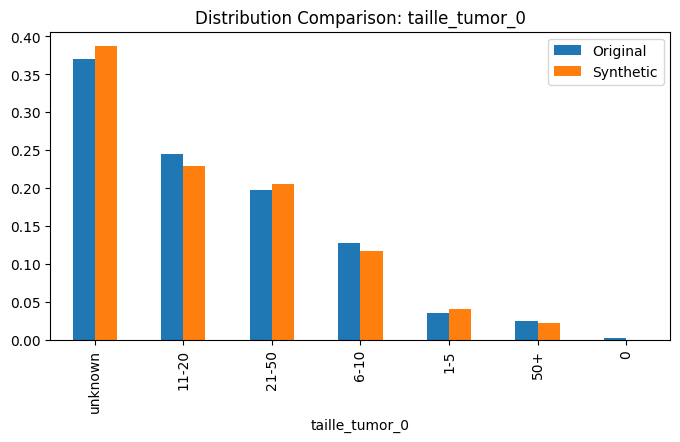

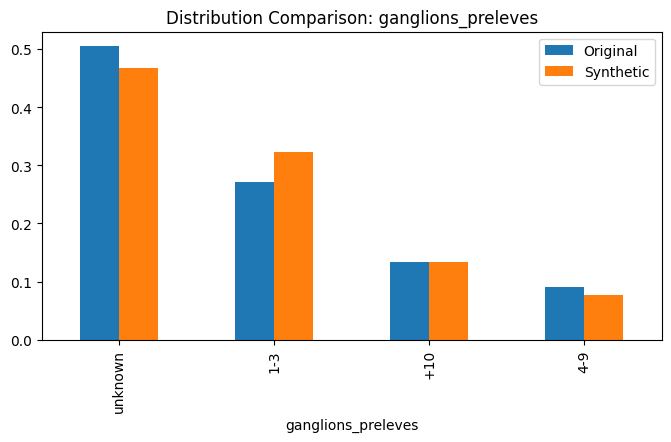

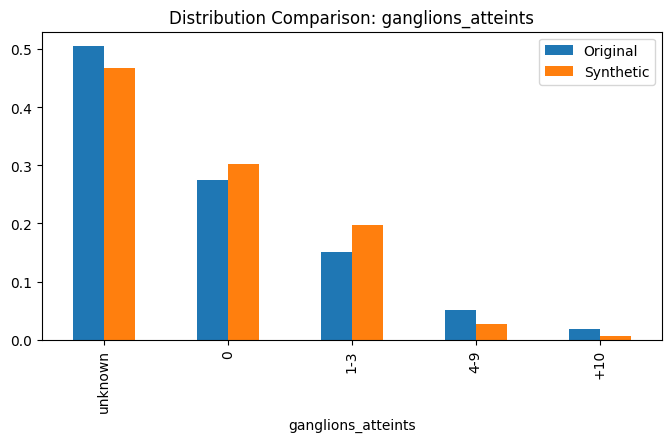

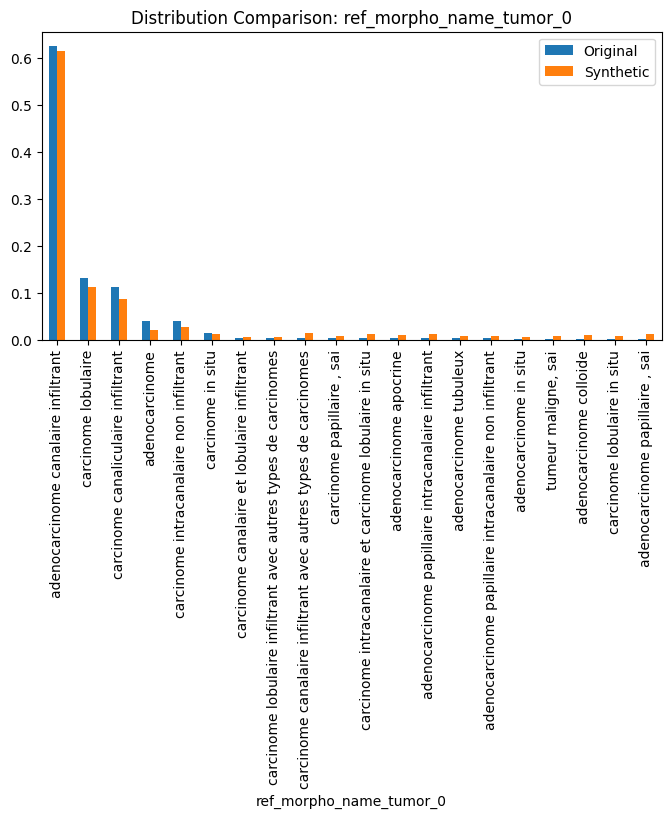

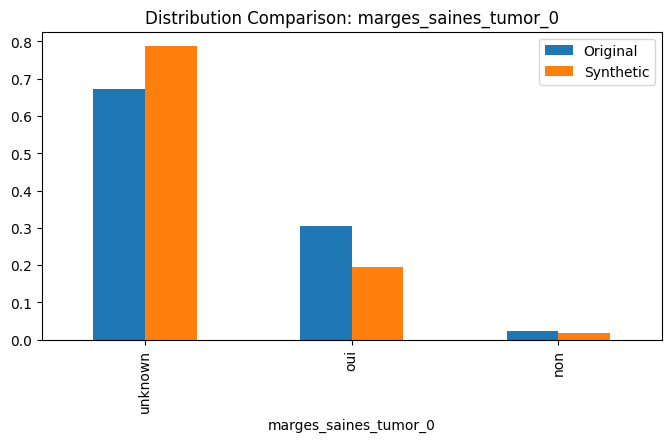

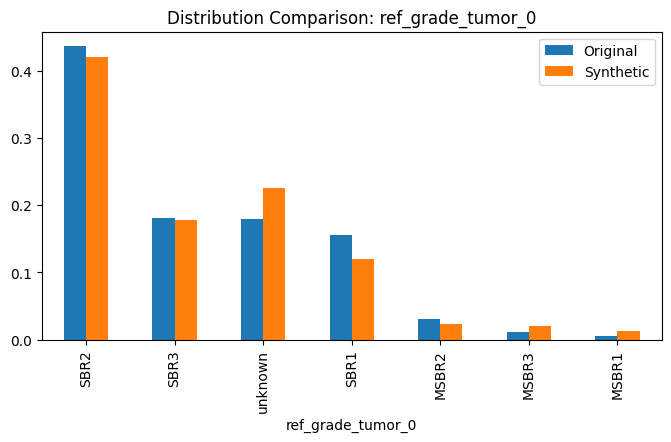

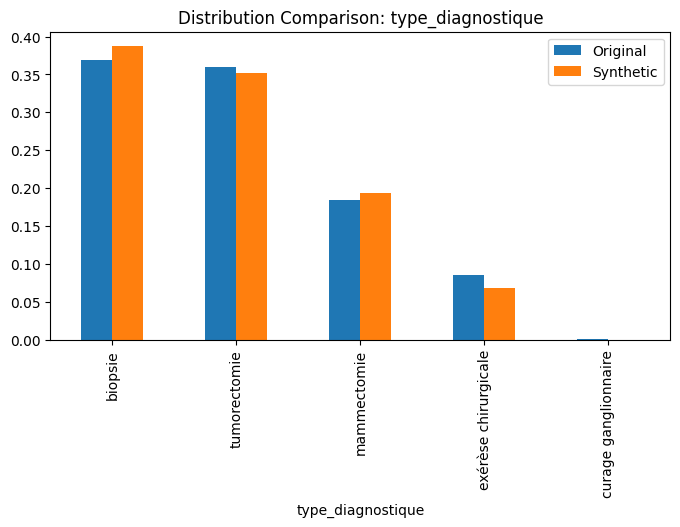

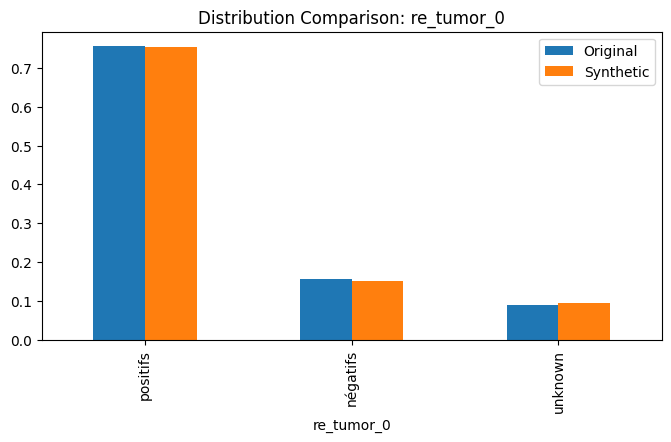

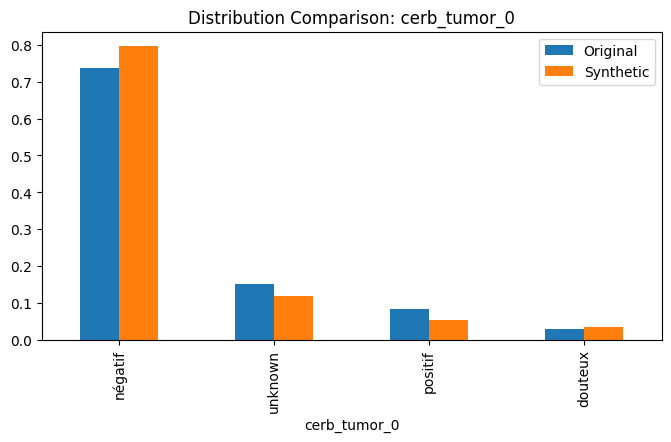

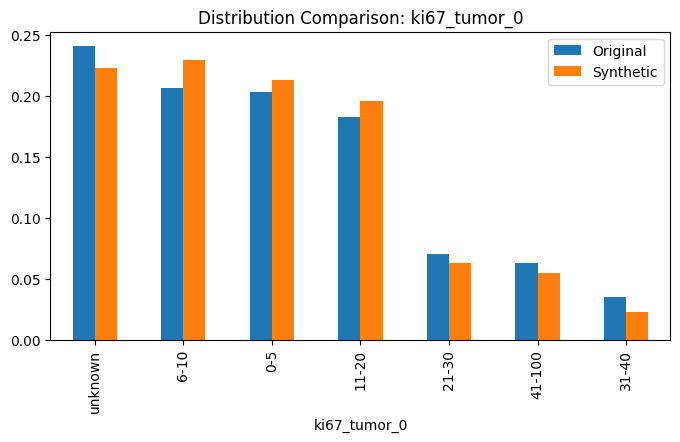

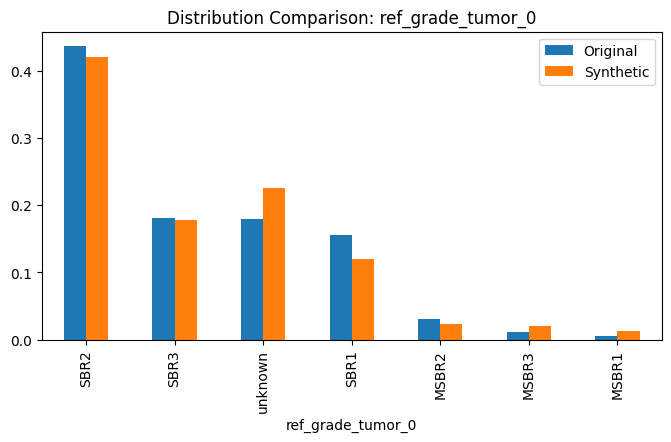

In [33]:
def compare_marginals(original_df, synthetic_df, attribute):
    orig_dist = original_df[attribute].value_counts(normalize=True)
    synth_dist = synthetic_df[attribute].value_counts(normalize=True)
    combined = pd.concat([orig_dist, synth_dist], axis=1, keys=['Original', 'Synthetic']).fillna(0)

    combined.plot(kind='bar', figsize=(8, 4), title=f"Distribution Comparison: {attribute}")
compare_marginals(df_train70,train_df, "taille_tumor_0")
compare_marginals(df_train70,train_df, "ganglions_preleves")
compare_marginals(df_train70,train_df, "ganglions_atteints")
compare_marginals(df_train70,train_df, "ref_morpho_name_tumor_0")
compare_marginals(df_train70,train_df, "marges_saines_tumor_0")
compare_marginals(df_train70,train_df, "ref_grade_tumor_0")
compare_marginals(df_train70,train_df, "type_diagnostique")
compare_marginals(df_train70,train_df, "re_tumor_0")
compare_marginals(df_train70,train_df, "cerb_tumor_0")
compare_marginals(df_train70,train_df, "ki67_tumor_0")
compare_marginals(df_train70,train_df, "ref_grade_tumor_0")
# compare_marginals(oneTumor_df,df_synthetic_caspailleur, "ki67_tumor_0")

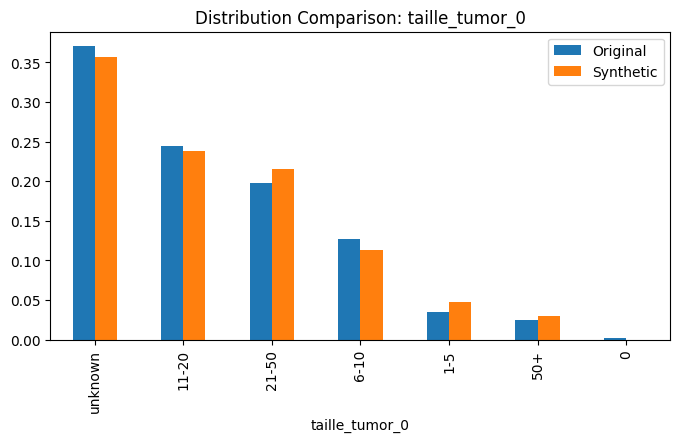

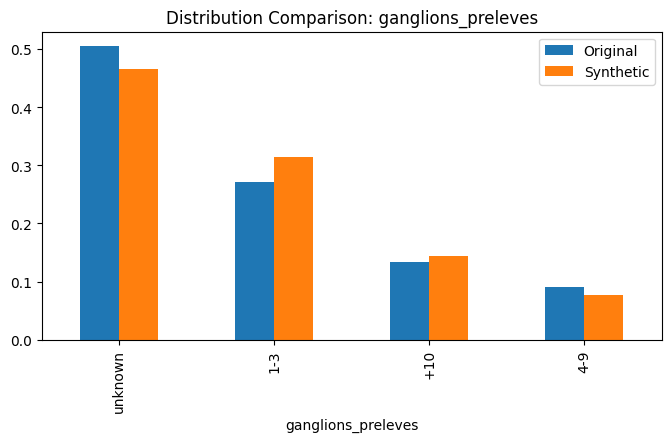

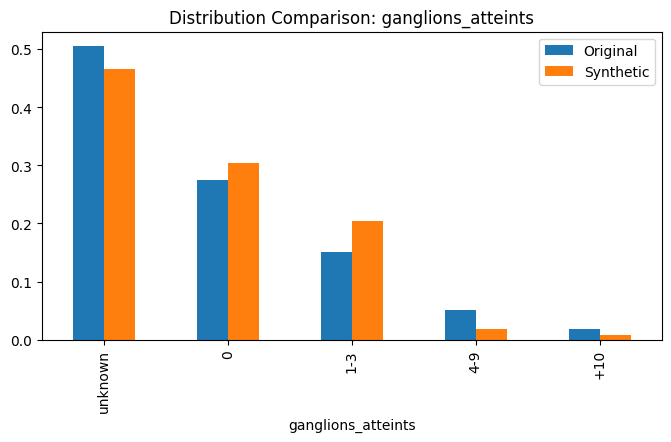

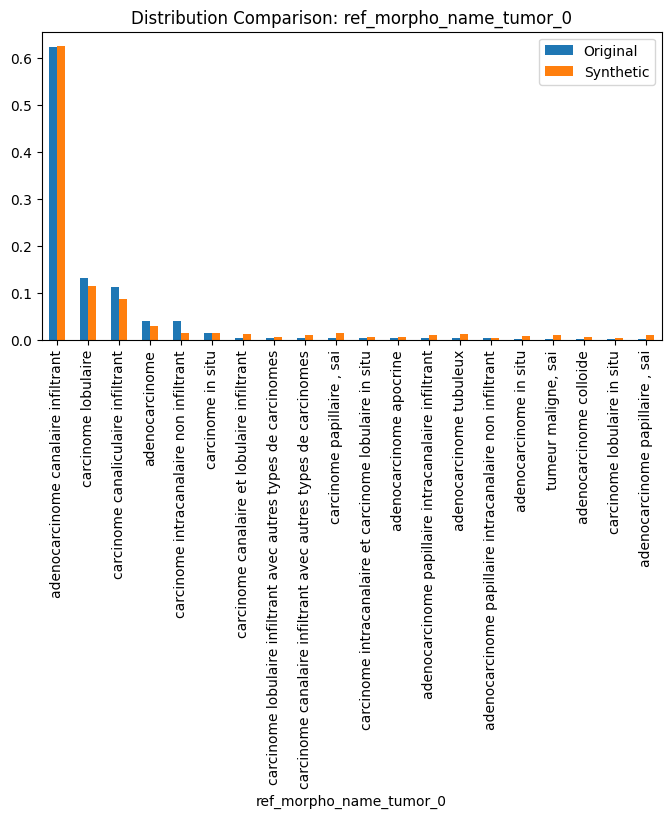

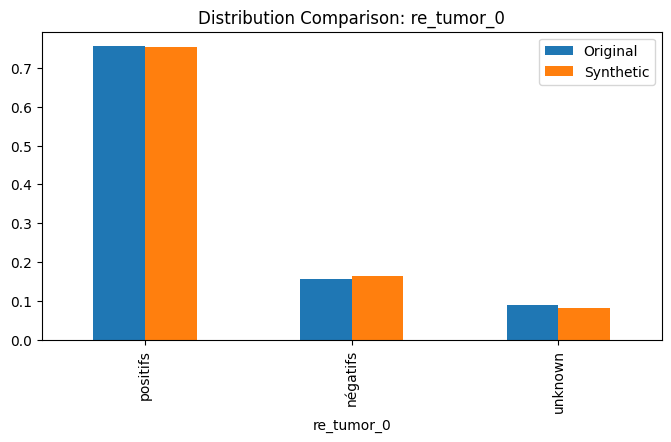

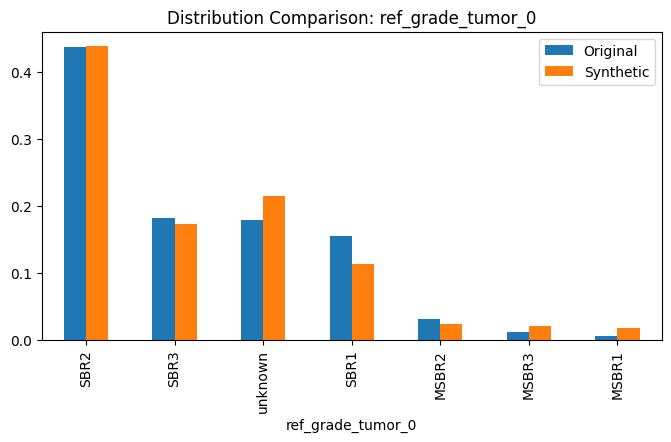

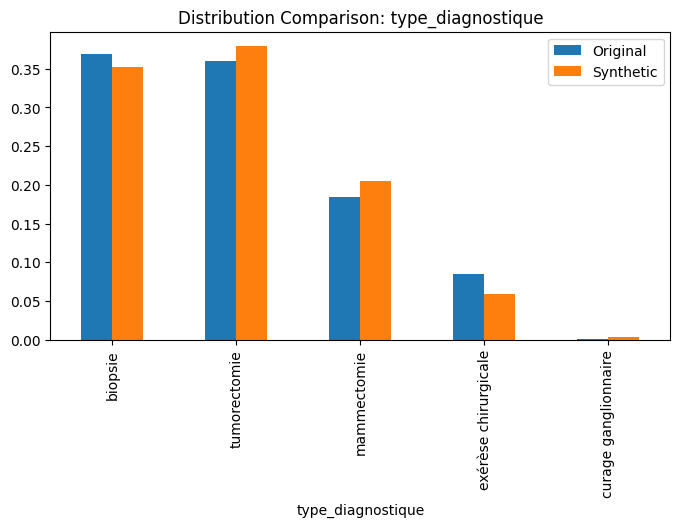

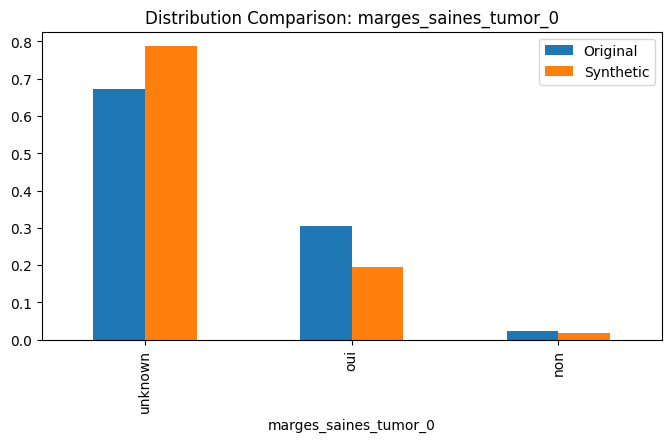

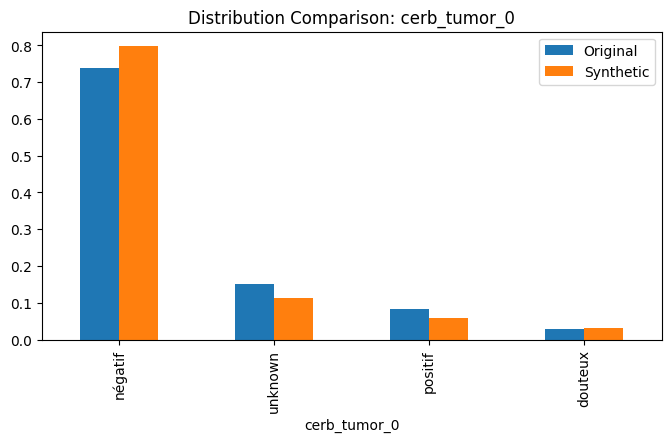

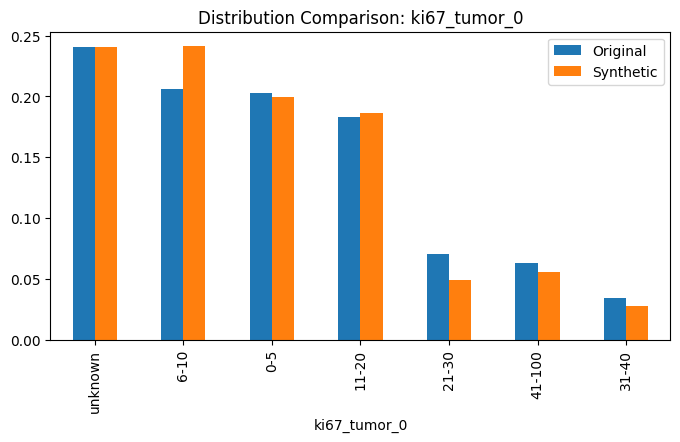

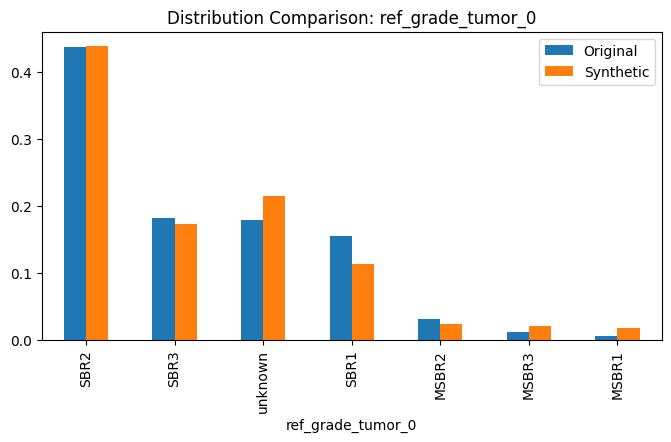

In [34]:
def compare_marginals(original_df, synthetic_df, attribute):
    orig_dist = original_df[attribute].value_counts(normalize=True)
    synth_dist = synthetic_df[attribute].value_counts(normalize=True)
    combined = pd.concat([orig_dist, synth_dist], axis=1, keys=['Original', 'Synthetic']).fillna(0)

    combined.plot(kind='bar', figsize=(8, 4), title=f"Distribution Comparison: {attribute}")
compare_marginals(df_train70,test_df, "taille_tumor_0")
compare_marginals(df_train70,test_df, "ganglions_preleves")
compare_marginals(df_train70,test_df, "ganglions_atteints")
compare_marginals(df_train70,test_df, "ref_morpho_name_tumor_0")
compare_marginals(df_train70,test_df, "re_tumor_0")
compare_marginals(df_train70,test_df, "ref_grade_tumor_0")
compare_marginals(df_train70,test_df, "type_diagnostique")
compare_marginals(df_train70,train_df, "marges_saines_tumor_0")
compare_marginals(df_train70,test_df, "cerb_tumor_0")
compare_marginals(df_train70,test_df, "ki67_tumor_0")
compare_marginals(df_train70,test_df, "ref_grade_tumor_0")
# compare_marginals(oneTumor_df,df_synthetic_caspailleur, "ki67_tumor_0")

### save to json and csv file

In [29]:
# Save to JSON
train_df.to_json("data/tabular/ddkdSplit/train_split.json", orient="records", indent=2)
test_df.to_json("data/tabular/ddkdSplit/test_split.json", orient="records", indent=2)

# Save to CSV
train_df.to_csv("data/tabular/ddkdSplit/train_split.csv", index=False)
test_df.to_csv("data/tabular/ddkdSplit/test_split.csv", index=False)

In [30]:
unique_values = {col: train_df[col].unique() for col in train_df.columns}
unique_values

{'type_diagnostique': array(['exérèse chirurgicale', 'biopsie', 'tumorectomie', 'mammectomie'],
       dtype=object),
 'ganglions_preleves': array(['4-9', '1-3', '+10', 'unknown'], dtype=object),
 'ganglions_atteints': array(['1-3', '4-9', 'unknown', '0', '+10'], dtype=object),
 'rupture_capsulaire': array(['unknown', 'non', 'oui'], dtype=object),
 'taille_tumor_0': array(['11-20', 'unknown', '6-10', '21-50', '50+', '1-5'], dtype=object),
 're_tumor_0': array(['positifs', 'unknown', 'négatifs'], dtype=object),
 'rp_tumor_0': array(['négatifs', 'positifs', 'unknown'], dtype=object),
 'embols_vasculaires_tumor_0': array(['unknown', '0', '1'], dtype=object),
 'cerb_tumor_0': array(['négatif', 'unknown', 'douteux', 'positif'], dtype=object),
 'marges_saines_tumor_0': array(['oui', 'unknown', 'non'], dtype=object),
 'ki67_tumor_0': array(['unknown', '6-10', '0-5', '11-20', '21-30', '41-100', '31-40'],
       dtype=object),
 'ref_morpho_name_tumor_0': array(['adenocarcinome', 'carcinome lobu

## distribution of duplicated rows: 


In [31]:
# count copies of each exact row
dup_counts = (
    final_valid_rows_pate.groupby(list(final_valid_rows_pate.columns), dropna=False)
      .size()
      .reset_index(name='n_copies')
      .sort_values('n_copies', ascending=False)
      .reset_index(drop=True)
)

# keep only rows that appear more than once
duplicates_only = dup_counts[dup_counts['n_copies'] > 1].copy()

# print("Number of duplicated row patterns:", len(duplicates_only))
# print("Total number of rows that belong to duplicate patterns:", duplicates_only['n_copies'].sum())
# print(duplicates_only.head(20))
copy_distribution = (
    duplicates_only['n_copies']
    .value_counts()
    .sort_index()
    .rename_axis('n_copies')
    .reset_index(name='n_row_patterns')
)

print(copy_distribution)

   n_copies  n_row_patterns
0         2              62
1         3              22
2         4               4
3         5               3
4         7               2
